In [1]:
import os, subprocess

REPO_URL = "https://github.com/tongyuguo/HelpHerInvest.git"
REPO_DIR = "HelpHerInvest"
data_dir = os.path.join(REPO_DIR, "Data")

def clone_or_pull():
    if os.path.isdir(os.path.join(REPO_DIR, ".git")):
        subprocess.run(["git", "-C", REPO_DIR, "pull"])
    else:
        subprocess.run(["git", "clone", REPO_URL])

clone_or_pull()

Already up to date.


In [2]:
import pandas as pd
import zipfile

zip_path = "HelpHerInvest/Data/stock_symbols_new.csv.zip"

with zipfile.ZipFile(zip_path) as z:
    df = pd.read_csv(z.open("stock_symbols_new.csv"))

df.head()

/tmp/ipykernel_2428761/1261020715.py:7: DtypeWarning: Columns (54,204,212,213,214,220,221,222,223) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(z.open("stock_symbols_new.csv"))


,symbol,company_name,address1,city,state,zip,country,phone,website,industry,...,address3,morningStarOverallRating,morningStarRiskRating,annualReportExpenseRatio,lastCapGain,annualHoldingsTurnover,prevTicker,tickerChangeDate,newListingDate,delistingDate
0,NVDA,NVIDIA CORP,2788 San Tomas Expressway,Santa Clara,CA,95051,United States,408 486 2000,https://www.nvidia.com,Semiconductors,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GOOGL,Alphabet Inc.,1600 Amphitheatre Parkway,Mountain View,CA,94043,United States,650-253-0000,https://abc.xyz,Internet Content & Information,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AAPL,Apple Inc.,One Apple Park Way,Cupertino,CA,95014,United States,(408) 996-1010,https://www.apple.com,Consumer Electronics,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MSFT,MICROSOFT CORP,One Microsoft Way,Redmond,WA,98052-6399,United States,425 882 8080,https://www.microsoft.com,Software - Infrastructure,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AMZN,AMAZON COM INC,410 Terry Avenue North,Seattle,WA,98109-5210,United States,206 266 1000,https://www.amazon.com,Internet Retail,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
import numpy as np
import re
import ast
import unicodedata
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Drop rows with missing symbol (ID)
df = df.dropna(subset=["symbol"]).copy()

# Convert common placeholder strings to NA
PLACEHOLDERS = {"[]": np.nan, "None": np.nan, "nan": np.nan, "NaN": np.nan, "": np.nan}
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].replace(PLACEHOLDERS)


# Parse companyOfficers into plain text
def parse_officers(officers_str):
    if pd.isna(officers_str):
        return []
    try:
        parsed = ast.literal_eval(officers_str)
        return parsed if isinstance(parsed, list) else []
    except Exception:
        return []

def officers_to_text(officers):
    parts = []
    for o in officers:
        if not isinstance(o, dict):
            continue
        name = o.get("name")
        title = o.get("title")
        if name and title:
            parts.append(f"{name} - {title}")
        elif name:
            parts.append(str(name))
        elif title:
            parts.append(str(title))
    return "; ".join(parts)

df["companyOfficers_parsed"] = df["companyOfficers"].apply(parse_officers)
df["companyOfficers_text"] = df["companyOfficers_parsed"].apply(officers_to_text)

# Build the raw NLP document per company
def join_text(*items):
    items = [x for x in items if isinstance(x, str) and x.strip()]
    return " ".join(items).strip()

df["document_raw"] = df.apply(
    lambda r: join_text(
        r.get("company_name"),
        r.get("sector"),
        r.get("industry"),
        r.get("longBusinessSummary"),
        r.get("companyOfficers_text"),
    ),
    axis=1
)

# Keep only rows with some text
df = df[df["document_raw"].str.len().fillna(0) > 0].copy()

# Text cleaning for NLP
URL_RE = re.compile(r"https?://\S+|www\.\S+", re.IGNORECASE)
EMAIL_RE = re.compile(r"\b[\w\.-]+@[\w\.-]+\.\w+\b")
HTML_RE = re.compile(r"<.*?>")
NON_WORD_RE = re.compile(r"[^a-z\s]") 
MULTISPACE_RE = re.compile(r"\s+")


def clean_text_minimal(text: str) -> str:
    if pd.isna(text):
        return ""

    # Unicode normalize
    text = unicodedata.normalize("NFKC", str(text))

    # Remove HTML, URLs, emails
    text = re.sub(HTML_RE, " ", text)
    text = re.sub(URL_RE, " ", text)
    text = re.sub(EMAIL_RE, " ", text)

    # Lowercase + whitespace normalize
    text = text.lower()
    text = re.sub(MULTISPACE_RE, " ", text).strip()
    return text

def clean_text_for_tfidf(text: str, remove_stopwords: bool = True) -> str:
    text = clean_text_minimal(text)
    text = re.sub(NON_WORD_RE, " ", text)
    text = re.sub(MULTISPACE_RE, " ", text).strip()

    if remove_stopwords:
        tokens = [t for t in text.split() if t not in ENGLISH_STOP_WORDS and len(t) > 2]
        text = " ".join(tokens)

    return text

df["document_clean_tfidf"] = df["document_raw"].apply(clean_text_for_tfidf)

# 5) Save cleaned dataset for modeling
cols_to_save = [
    "symbol",
    "company_name",
    "sector",
    "industry",
    "document_raw",
    "document_clean_tfidf",
]

df[cols_to_save].to_csv(os.path.join(data_dir, "nlp_clean_stock_symbols.csv"), index=False)
print("Saved:", "nlp_clean_stock_symbols.csv", "rows:", len(df))

/tmp/ipykernel_2428761/1992669788.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(PLACEHOLDERS)


Saved: nlp_clean_stock_symbols.csv rows: 10283


In [4]:
def can_push():
    result = subprocess.run(
        ["git", "-C", REPO_DIR, "push", "--dry-run"],
        capture_output=True, text=True
    )
    return result.returncode == 0

def commit_and_push(msg="update"):
    subprocess.run(["git", "-C", REPO_DIR, "add", "-A"])
    subprocess.run(["git", "-C", REPO_DIR, "commit", "-m", msg])
    subprocess.run(["git", "-C", REPO_DIR, "push"])

if can_push():
    commit_and_push("update notebook / data")
else:
    print("Not a collaborator — skipping push")

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


Everything up-to-date


In [5]:
#import yfinance as yf
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

9731
Date                  0
Ticker                0
mom_1m                0
mom_3m              100
mom_6m              250
mom_12m             546
mom_12m_ex_1m       546
rel_3m_spy          100
rel_6m_spy          250
rel_12m_spy         546
vol_3m              100
vol_6m              250
drawdown_6m         200
drawdown_12m        497
pct_above_200dma    403
adj_close             0
fwd_excess          150
fwd_return          150
dtype: int64


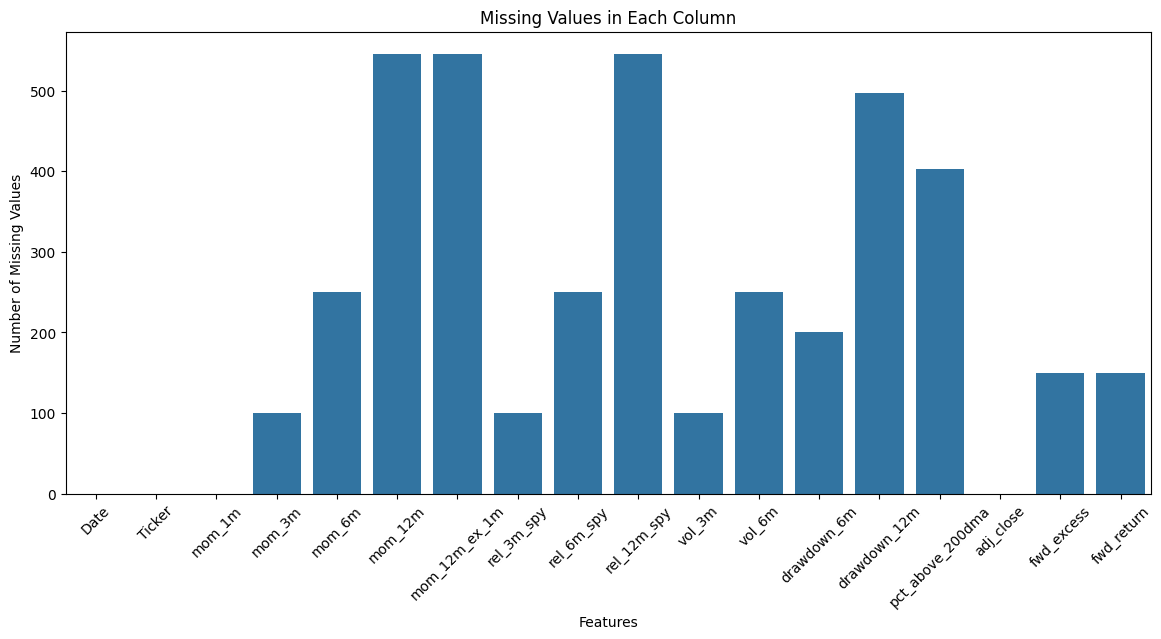

In [6]:
data_path = "HelpHerInvest/Data/final_dataset.csv"

# Load Data
df = pd.read_csv(data_path)
print(len(df.index))
# Check for missing values
print(df.isnull().sum())

# Plot bar plot of the missing values
missing_values = df.isnull().sum()
plt.figure(figsize=(14, 6))
sns.barplot(x=missing_values.index, y=missing_values.values)
plt.xticks(rotation=45)
plt.title("Missing Values in Each Column")
plt.xlabel("Features")
plt.ylabel("Number of Missing Values")
plt.show()

Date                0.000000
Ticker              0.000000
mom_1m              0.000000
mom_3m              1.027644
mom_6m              2.569109
mom_12m             5.610934
mom_12m_ex_1m       5.610934
rel_3m_spy          1.027644
rel_6m_spy          2.569109
rel_12m_spy         5.610934
vol_3m              1.027644
vol_6m              2.569109
drawdown_6m         2.055287
drawdown_12m        5.107389
pct_above_200dma    4.141404
adj_close           0.000000
fwd_excess          1.541465
fwd_return          1.541465
dtype: float64


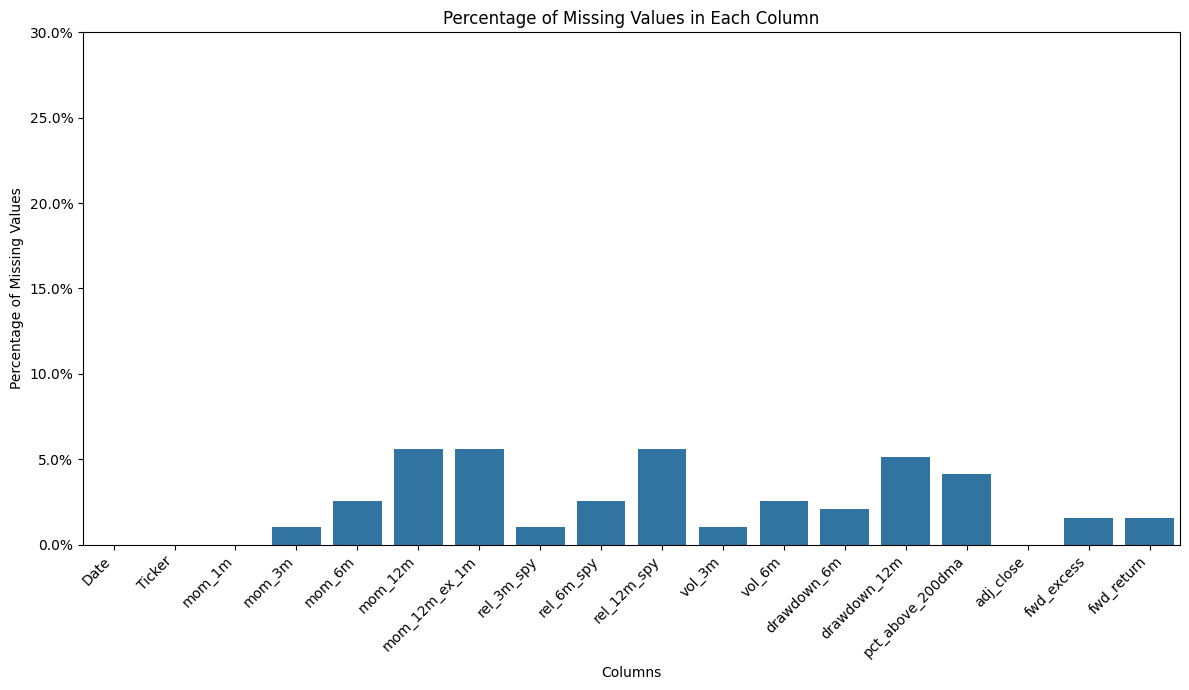

In [7]:
import matplotlib.ticker as mtick

# Nulls Per Column  
nulls_per_column = df.isnull().sum()

# Percentage of Nulls Per Column
percentage_nulls_per_column = (nulls_per_column / len(df)) * 100
print(percentage_nulls_per_column)

plt.figure(figsize=(12, 7))
sns.barplot(x=percentage_nulls_per_column.index, y=percentage_nulls_per_column.values)

plt.xticks(rotation=45, ha="right")
plt.title("Percentage of Missing Values in Each Column")
plt.xlabel("Columns")
plt.ylabel("Percentage of Missing Values")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
plt.ylim(0, 30)

plt.tight_layout()  
plt.show()

In [8]:
# check if there are duplicate rows
num_dupes = df.duplicated().sum()

if num_dupes > 0:
    print("Duplicate rows found. Consider removing them.")
    # View duplicate rows
    dupe_rows = df[df.duplicated()]
    print(dupe_rows)
else:
    print("No duplicate rows found.")

# check if there are duplicate columns
dup_content_mask = df.T.duplicated().sum()

if dup_content_mask > 0:
    print("Duplicate columns found. Consider removing them.")
    # View duplicate columns
    dupe_cols = df.columns[df.T.duplicated()]
    print(dupe_cols)
else:
    print("No duplicate columns found.")

No duplicate rows found.
No duplicate columns found.


In [9]:
# Transpose the DataFrame and check for duplicated columns (rows)
dup_content_mask = df.T.duplicated()
dup_content_cols = df.columns[dup_content_mask]
print(f"Duplicate columns by content: {dup_content_cols.tolist()}")

Duplicate columns by content: []


In [10]:
# preprocess the data by dropping rows with missing values
print("Missing fwd_excess values:")
print(df[["Date","Ticker","fwd_excess"]].tail(5))

df_dropped = df.dropna()
print("---  ---  ---")
print("Length of original:",len(df.index))
print("Length of dropped:",len(df_dropped.index))
print("Sanity check - missing fwd_excess values after dropping:")
print(df_dropped[["Date","Ticker","fwd_excess"]].tail(5))

Missing fwd_excess values:
            Date Ticker  fwd_excess
9726  2026-02-28    NVS         NaN
9727  2026-02-28    AXP         NaN
9728  2026-02-28    NVO         NaN
9729  2026-02-28     PM         NaN
9730  2026-02-28    RTX         NaN
---  ---  ---
Length of original: 9731
Length of dropped: 9038
Sanity check - missing fwd_excess values after dropping:
            Date Ticker  fwd_excess
9576  2025-11-30    NVS    0.236199
9577  2025-11-30    AXP   -0.059055
9578  2025-11-30    NVO   -0.008354
9579  2025-11-30     PM    0.210935
9580  2025-11-30    RTX    0.150119


In [11]:
# Log the Adjusted Close
print(df_dropped["adj_close"].describe())
print("---  ---  ---")

df_dropped["log_adj_close"] = np.log(df_dropped["adj_close"])
print(df_dropped[["Date","Ticker","adj_close","log_adj_close"]].tail(10))

count    9038.000000
mean      100.666846
std       123.299178
min         0.210643
25%        30.451757
50%        61.107658
75%       120.027697
max      1075.469971
Name: adj_close, dtype: float64
---  ---  ---
            Date Ticker   adj_close  log_adj_close
9571  2025-11-30    IBM  306.830597       5.726296
9572  2025-11-30     GS  821.965088       6.711698
9573  2025-11-30    MRK  103.941612       4.643829
9574  2025-11-30   LRCX  155.743591       5.048211
9575  2025-11-30   HSBC   71.160004       4.264931
9576  2025-11-30    NVS  130.399994       4.870607
9577  2025-11-30    AXP  364.460358       5.898418
9578  2025-11-30    NVO   49.349998       3.898938
9579  2025-11-30     PM  156.056625       5.050219
9580  2025-11-30    RTX  174.910004       5.164272


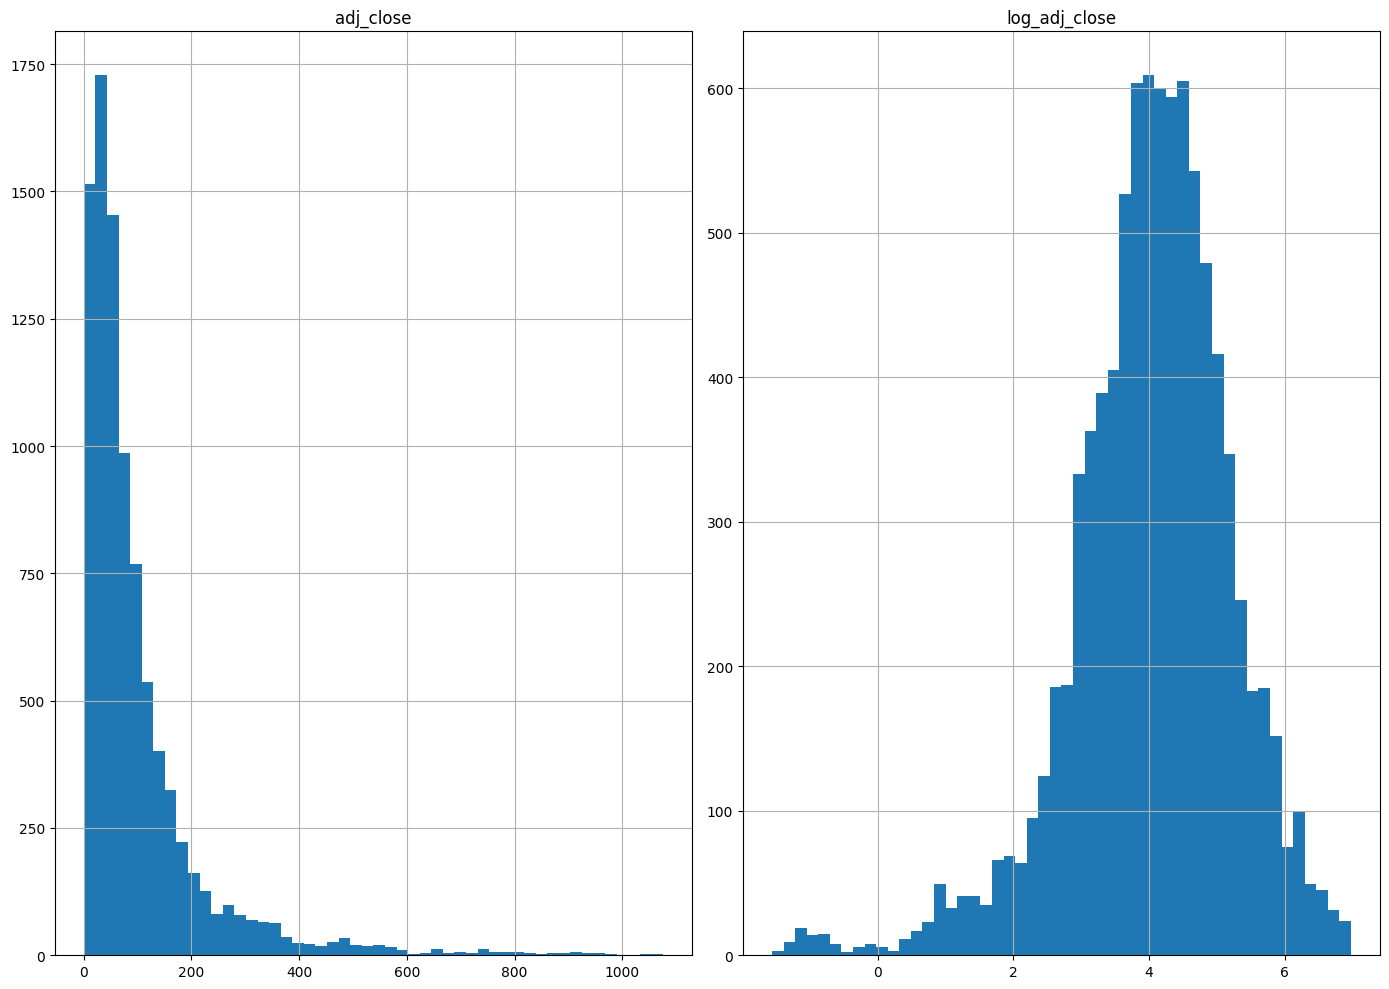

In [12]:
# Histogram of variables
cols = df_dropped.columns.drop(['fwd_excess','Date'])
df_dropped[["adj_close","log_adj_close"]].hist(figsize=(14, 10), bins=50)
plt.tight_layout()
plt.show()